# Epidemiological Model: Setup & Imports

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


# Mathematical equations and simulation runner from the lab

In [19]:
# Define the SIRD differential equations used by every simulation.
def sird_model(y, t, beta, gamma, mu):
    """Return the rates of change for the SIRD compartments."""
    S, I, R, D = y
    N = S + I + R + D

    # Infectious individuals leave I through recovery or disease-related death.
    new_infections = beta * S * I / N
    recoveries = gamma * I
    deaths = mu * I

    dSdt = -new_infections
    dIdt = new_infections - recoveries - deaths
    dRdt = recoveries
    dDdt = deaths

    return dSdt, dIdt, dRdt, dDdt

# A small numerical check confirms that the model returns four compartment rates.
test_result = sird_model([990, 10, 0, 0], 0, 0.3, 0.1, 0.01)
print(f"SIRD test result: {test_result}")
print("The model returns one rate for S, I, R, and D.")

SIRD test result: (-2.97, 1.87, 1.0, 0.1)
The model returns one rate for S, I, R, and D.


In [20]:
def run_sird_simulation(beta, gamma, mu, N=1000, I0=10, days=150, plot=False):
    """
    Simulate epidemic trajectory using the SIRD model.
    """
    S0 = N - I0
    R0 = 0
    D0 = 0
    y0 = [S0, I0, R0, D0]

    t = np.linspace(0, days - 1, days)

    # Solve SIRD equations
    sol = odeint(sird_model, y0, t, args=(beta, gamma, mu))
    S, I, R, D = sol.T

    if plot:
        plt.figure(figsize=(10, 6))
        plt.plot(t, S, 'b-', label='Susceptible', linewidth=2)
        plt.plot(t, I, 'r-', label='Infectious', linewidth=2)
        plt.plot(t, R, 'g-', label='Recovered', linewidth=2)
        plt.plot(t, D, 'k-', label='Deaths', linewidth=2)
        plt.xlabel('Time (days)')
        plt.ylabel('Population')
        plt.title(f'SIRD Model: β={beta}, γ={gamma}, μ={mu}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return t, S, I, R, D

## Part 1: Parameter Analysis Function
We compare five recovery rates while holding transmission, mortality, population size, and initial infections constant. For each value, the table records the reproduction number, the maximum number infectious at one time, when that maximum occurs, and cumulative deaths at the end of the simulation.

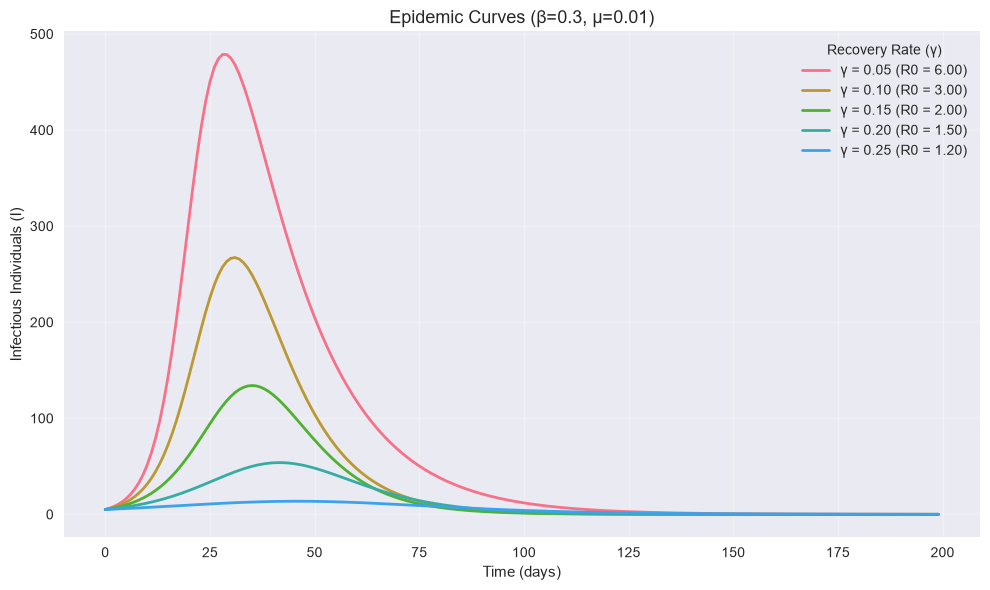

,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,6.0,478.629011,29.0,165.503151
1,0.10,3.0,267.257642,31.0,83.527144
2,0.15,2.0,134.079124,35.0,47.578589
3,0.20,1.5,53.821447,42.0,25.708382
4,0.25,1.2,13.656717,46.0,10.686007


In [21]:
def analyze_recovery_rates(beta, mu, N, I0, simulation_days, ax=None):
    """
    Analyze epidemic outcomes for different recovery rates.

    Parameters:
    -----------
    beta : float
        Transmission rate
    mu : float
        Mortality rate
    N : int
        Total population
    I0 : int
        Initial infected individuals
    simulation_days : int
        Simulation duration in days

    Returns:
    --------
    pandas.DataFrame
        Results summary for each recovery rate with columns:
        ['gamma', 'R0', 'peak_infected', 'peak_day', 'total_deaths']
    """
    gamma_values = [0.05, 0.10, 0.15, 0.20, 0.25]
    records = []

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
        show_plot = True
    else:
        show_plot = False

    for gamma in gamma_values:

        t_sird, S, I, R, D = run_sird_simulation(
            beta=beta, gamma=gamma, mu=mu, N=N, I0=I0, days=simulation_days, plot=False
        )

        # r0 that was specified in assingment (no deaths included)
        r0 = beta / (gamma)  # changed this, becuase in rubric it said to use this version i believe?
        peak_index = int(np.argmax(I))
        peak_day = t_sird[peak_index]
        peak_infected = np.max(I)
        total_deaths = D[-1]

        # Plot each infectious curve on the same figure
        ax.plot(t_sird, I, linewidth=2, label=f'γ = {gamma:.2f} (R0 = {r0:.2f})')

        # Epidemic duration: first day after the peak where infectious individuals drop below 1
        post_peak = np.where((t_sird >= peak_day) & (I < 1.0))[0]
        duration = t_sird[post_peak[0]] if len(post_peak) > 0 else simulation_days

        records.append({
            'gamma': gamma,
            'R0': r0,
            'peak_infected': peak_infected,
            'peak_day': peak_day,
            'total_deaths': total_deaths,
        })

    ax.set_title(f'Epidemic Curves (β={beta}, μ={mu})', fontsize=13)
    ax.set_xlabel('Time (days)', fontsize=11)
    ax.set_ylabel('Infectious Individuals (I)', fontsize=11)
    ax.legend(title='Recovery Rate (γ)', fontsize=10)
    ax.grid(True, alpha=0.3)

    if show_plot:
        plt.tight_layout()
        plt.show()

    return pd.DataFrame(records)

# Test the function to demonstrate Part 1 works
test_results = analyze_recovery_rates(beta=0.3, mu=0.01, N=1000, I0=5, simulation_days=200)
display(test_results)

## Part 2: Scenario Comparison

The formatted table below makes the effect of faster recovery easy to compare across the selected parameter values.

,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,8.000000,520.582635,21.0,284.757361
1,0.10,4.000000,340.140583,22.0,159.892366
2,0.15,2.666667,213.465894,24.0,102.610885
3,0.20,2.000000,123.893909,27.0,67.423926
4,0.25,1.600000,63.051893,30.0,42.694003


,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,4.000000,371.356334,44.0,88.224137
1,0.10,2.000000,139.333450,52.0,36.699911
2,0.15,1.333333,31.340756,67.0,13.640017
3,0.20,1.000000,5.000000,0.0,1.831032
4,0.25,0.800000,5.000000,0.0,0.433166


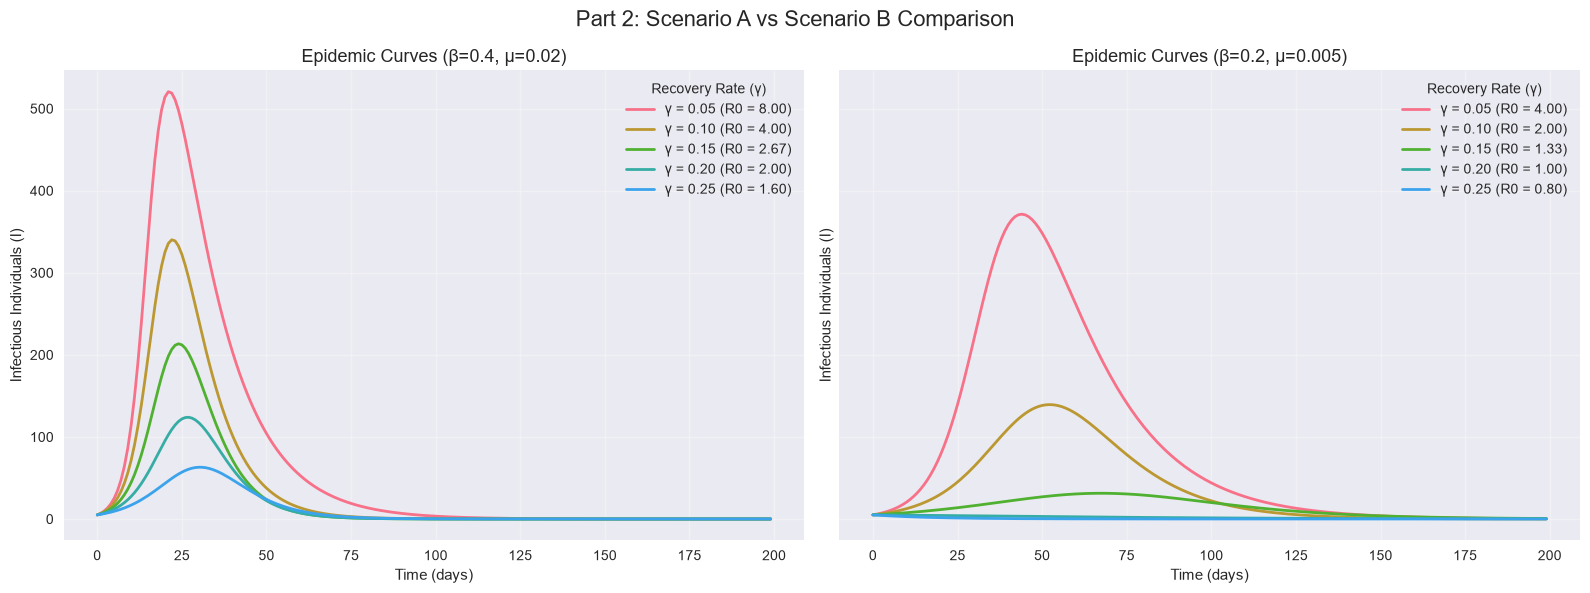

In [22]:
# Create a 1-row, 2-column figure with a shared Y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Run the functions and pass the corresponding axes
results1 = analyze_recovery_rates(beta=0.4, mu=0.02, N=1000, I0=5, simulation_days=200, ax=ax1)
results2 = analyze_recovery_rates(beta=0.2, mu=0.005, N=1000, I0=5, simulation_days=200, ax=ax2)

display(results1)
display(results2)

# Give the overall figure a title
plt.suptitle('Part 2: Scenario A vs Scenario B Comparison', fontsize=16)
plt.tight_layout()
plt.show()


We compare two 200-day scenarios using the same five recovery rates. Scenario A represents high transmission and mortality; Scenario B represents lower transmission and mortality. The tables and figure below use identical metrics and formatting so the public-health trade-off is easy to inspect.

**Scenario A — High transmission:** $\beta=0.4$, $\mu=0.02$, $N=1000$, $I_0=5$

**Scenario B — Low transmission:** $\beta=0.2$, $\mu=0.005$, $N=1000$, $I_0=5$

#### Scenario comparison figure

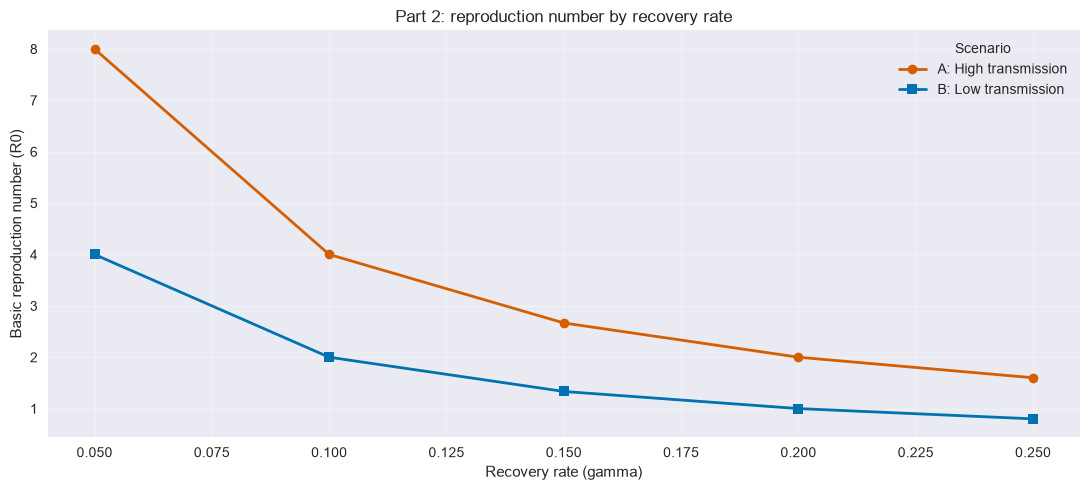

In [23]:
plt.figure(figsize=(11, 5))
plt.plot(
    results1['gamma'],
    results1['R0'],
    marker='o', linewidth=2, label='A: High transmission',
    color='#D55E00'
)
plt.plot(
    results2['gamma'],
    results2['R0'],
    marker='s', linewidth=2, label='B: Low transmission',
    color='#0072B2'
)
plt.xlabel('Recovery rate (gamma)')
plt.ylabel('Basic reproduction number (R0)')
plt.title('Part 2: reproduction number by recovery rate')
plt.legend(title='Scenario')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Part 2: Scenario Comparison Analysis

There are numerous reasons for scenario A being worse than scenario B, the first being that scenario A has double the transmission rate, because of this this scenario will peak earlier, while also having a higher peak infection wise, this could overload healthcare systems because over 520 people get sick at once which is half the town. Scenario B peaks later at day 44 with 371 (this 520 vs 371 is based on a recovery rate of 0.05). Another reason that scenario A is worse is because scenario A has 4 times higher mortality rate, so this then combines with higher cases to have much more deaths as well, (285 vs 88.2). In Scenario A, R₀ is above 1 at every recovery rate tested. In Scenario B, R₀ equals 1 at γ = 0.20 and falls below 1 at γ = 0.25. 

### The following code is strictly for reproducibility purpose, and could be skipped over if neccesary.

In [24]:
# for cloud-notebook
# !pip freeze > requirements.txt

# for conda
# !conda env export > environment.yml

## Part 3: Policy Recommendations

### 3.1 Parameter impact analysis

Increasing the recovery rate reduces peak infections and total deaths:

- **Peak infections fall sharply.** In Scenario A, the peak drops from about 521 people at γ = 0.05 to about 63 at γ = 0.25, an 88% reduction. In Scenario B, the peak falls from about 371 to 5 people over the same range.
- **Total deaths fall sharply.** In Scenario A, deaths fall from about 285 at γ = 0.05 to about 43 at γ = 0.25, an 85% reduction.
- **Epidemic duration also changes.** Defining duration as the time from the start until infections fall below 1 person after the peak, Scenario A lasts about 118 days at γ = 0.05 and 84 days at γ = 0.25. However, duration does not decrease at every step: it reaches 77 days at γ = 0.15 before increasing again.

Faster recovery means people spend less time infectious, reducing opportunities to infect others. A lower peak could also reduce pressure on healthcare services because fewer people may need care at the same time.

### 3.2 Intervention analysis

In [25]:
baseline_gamma = 0.10
intervention_gamma = baseline_gamma * 1.5  # a 50% increase

_, _, _, _, deaths_baseline = run_sird_simulation(
    beta=0.4, gamma=baseline_gamma, mu=0.02, N=1000, I0=5, days=200
)
_, _, _, _, deaths_intervention = run_sird_simulation(
    beta=0.4, gamma=intervention_gamma, mu=0.02, N=1000, I0=5, days=200
)

total_deaths_baseline = deaths_baseline[-1]
total_deaths_intervention = deaths_intervention[-1]
deaths_averted = total_deaths_baseline - total_deaths_intervention
pct_reduction = deaths_averted / total_deaths_baseline * 100

print(f"Baseline gamma = {baseline_gamma:.2f}  ->  total deaths = {total_deaths_baseline:.1f}")
print(f"Intervention gamma = {intervention_gamma:.2f} (+50%)  ->  total deaths = {total_deaths_intervention:.1f}")
print(f"Deaths averted = {deaths_averted:.1f}  ({pct_reduction:.1f}% reduction)")

Baseline gamma = 0.10  ->  total deaths = 159.9
Intervention gamma = 0.15 (+50%)  ->  total deaths = 102.6
Deaths averted = 57.3  (35.8% reduction)


For this one let's look at the baseline of gamma = 0.1, in this case there are 159.9 deaths. If we change gamma to 0.15, which is a 50 percent boost, the deaths drop to 102.6. So 159.9 - 102.6 = 57.3 deaths less, and (57.3 / 159.9) * 100% = 35.8 percent reduction in total deaths. In this case quicker recovery prevents about 35.8% of baseline deaths in this simulation, without having to change beta through lockdowns or masks for example.

### 3.3 Real-world application

So to increase recovery rate we must look at things which have an impact after a person is already infected, so this wouldn't include vaccines. Some things for this are antivirals, looking online for covid it would for example be a drug called paxlovid that could help. So vaccines would impact beta, and antivirals would impact gamma. An example is Tamiflu (oseltamivir) for the flu. Its mechanism is blocking the neuraminidase enzyme so the virus can't release from infected cells. According to CDC guidance, early treatment shortens illness duration by about one day, though symptom reduction doesn't mean gamma increases by that exact same percentage. So for example if a sample illness lasts 7 days so gamma 1/7, if we can reduce that to 6 days with antivirals, it would be 1/6 so a 16.66
 percent increase in recovery rate.